# Setup: Bộ dữ liệu text gồm 10 câu

In [35]:
import numpy as np

cau = [
    "Hello world",
    "Talk is cheap show me the code", 
    "This is not your ID card show me your code", 
    "No thing is more precious than independence and freedom", 
    "I am a student at Vietnam National University Ho Chi Minh City Ho Chi Minh City University of Technology", 
    "I major in computer science", 
    "Do you know that HCMUT and HUTECH are short for Ho Chi Minh City University of Technology", 
    "I hope I can learn much knowledge and gain skills about AI and Machine Learning after this course",
    "I think I will make it 10 sentences",
    "This is the 10th sentence and I thought it might be less"
]

## 1. Biểu diễn dữ liệu thành ma trận & độ tương đồng

### 1.1. Biến dữ liệu thành ma trận

In [36]:
vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in cau])
print(X.shape)

(10, 74)


Ma trận X có hàng là các câu, cột là các từ lần lượt trong vocab. Đối với mỗi câu, số lần xuất hiện của mỗi từ tương ứng được đếm và thể hiện qua điểm giao với các cột trong ma trận.

### 1.2. Phép toán cơ bản

In [37]:
# before
print("X:", X.shape)


# after
X_mean = np.mean(X, axis=0)
print("X_mean:", X_mean.shape)

X_minus = X - X_mean
print("X - X_mean:", X_minus.shape)

X: (10, 74)
X_mean: (74,)
X - X_mean: (10, 74)


Ma trận X ban đầu có kích thước (10, 74), trong đó 10 hàng đại diện cho 10 câu và 74 cột đại diện cho các từ ngữ xuất hiện trong 10 câu văn đó. 

**Vector trung bình theo cột** được tính bằng cách lấy trung bình các giá trị tương ứng theo trục 0. Kết quả là numpy thu gọn từ 10 hàng (câu) và trả về vector trung bình chỉ còn shape (74, ).

**Cơ chế broadcasting khi trừ trung bình** được thực hiện bằng cách lấy các hàng trong X trừ cho hàng duy nhất của ma trận thể hiện vector trung bình theo cột đã tính lúc trước, hoặc có thể xem là numpy tạo ra ma trận shape (10, 74) bằng cách nhân 10 lần vector trung bình để tiến hành trừ ma trận như bình thường.

### 1.3. Cosine Similarity

In [38]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

S = cosine_similarity(X)
print(S.shape)
# print(S)

(10, 10)


Khi không truyền tham số Y, hàm sẽ tự động dùng X cho Y, hay nói cách khác là nó sẽ so sánh từng cặp các câu trong X với chính nó và với tất cả các câu còn lại. 

Kết quả trả về là ma trận tương đồng. Trong đó ta thấy rằng khi một câu so sánh với chính nó thì độ tương đồng là 1, nếu hai câu không có từ chung thì độ tương đồng là 0. Cosine similarity đang thể hiện mức độ từ ngữ giống nhau xuất hiện trong câu, cũng chính là độ tương đồng giữa 2 câu trong tập dứ liệu.

### 1.4. Truy vấn

In [39]:
def search(query, top_k=3):
    v_query = to_vector(query)
    S = cosine_similarity(X, v_query.reshape(1, -1))
    top_k_index = np.argsort(S, axis=0).flatten()[:-top_k - 1:-1]
    top = [(cau[i], S[i, 0]) for i in top_k_index]
    return top
    
top_k = search("Talk less and show me the code")
print(top_k)

[('Talk is cheap show me the code', np.float64(0.7142857142857142)), ('This is the 10th sentence and I thought it might be less', np.float64(0.3273268353539886)), ('This is not your ID card show me your code', np.float64(0.3273268353539886))]


Hàm search trả về top k câu trong không gian ban đầu có độ tương đồng cao nhất với query. Hàm sau khi tính độ tương đồng thì tiến hành sort và slicing để lấy index của k kết quả độ tương đồng cao nhất.

### 1.5. Nhận xét

Với câu truy vấn *"Talk less and show me the code"*, top 3 câu có độ tương đồng cao nhất lần lượt là:
*'Talk is cheap show me the code'* - index 1 - similarity 0.7142857142857142
*'This is the 10th sentence and I thought it might be less'* - index 9 - similarity 0.3273268353539886
*'This is not your ID card show me your code'* - index 2 - similarity 0.3273268353539886

Trong đó, câu index 2 và index 9 có độ tương đồng với query như nhau.

Các câu với index 0, 4, 5, 8 không có từ trùng với query trong không gian vocab nên độ tương đồng bằng 0.

Khi xét đến trực giác con người, ta có thể dễ dàng thấy câu 1 thật sự có điểm tương đồng với query, câu 2 cũng vậy. Đối với câu 9 thì không cảm nhận được rõ ràng nhưng về số từ trùng khớp thì quả thật bằng với câu 2.

Từ đó, ta có nhân xét rằng Cosine Similarity theo cách hiện thực trên dựa vào tần suất từ trùng lặp một cách cơ học với câu truy vấn. Tuy nhiên, nó chưa hiểu được ngữ nghĩa sâu xa hoặc cấu trúc ngữ pháp theo trực giác con người.

## 2. Biến đổi tuyến tính & SVD

In [40]:
import matplotlib.pyplot as plt

### 2.1. Dùng lại ma trận X

In [41]:
print(X.shape)

(10, 74)


### 2.2. Giảm chiều bằng SVD

In [44]:
Xc = X - X. mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:,:2] * S[:2]

print(coords.shape)

(10, 2)


Từ ma trận (10, 71), SVD giảm chiều xuống thành (10, 2) thể hiện toạ độ mỗi câi trên mặt phẳng 2D.

### 2.3. Trực quan hoá

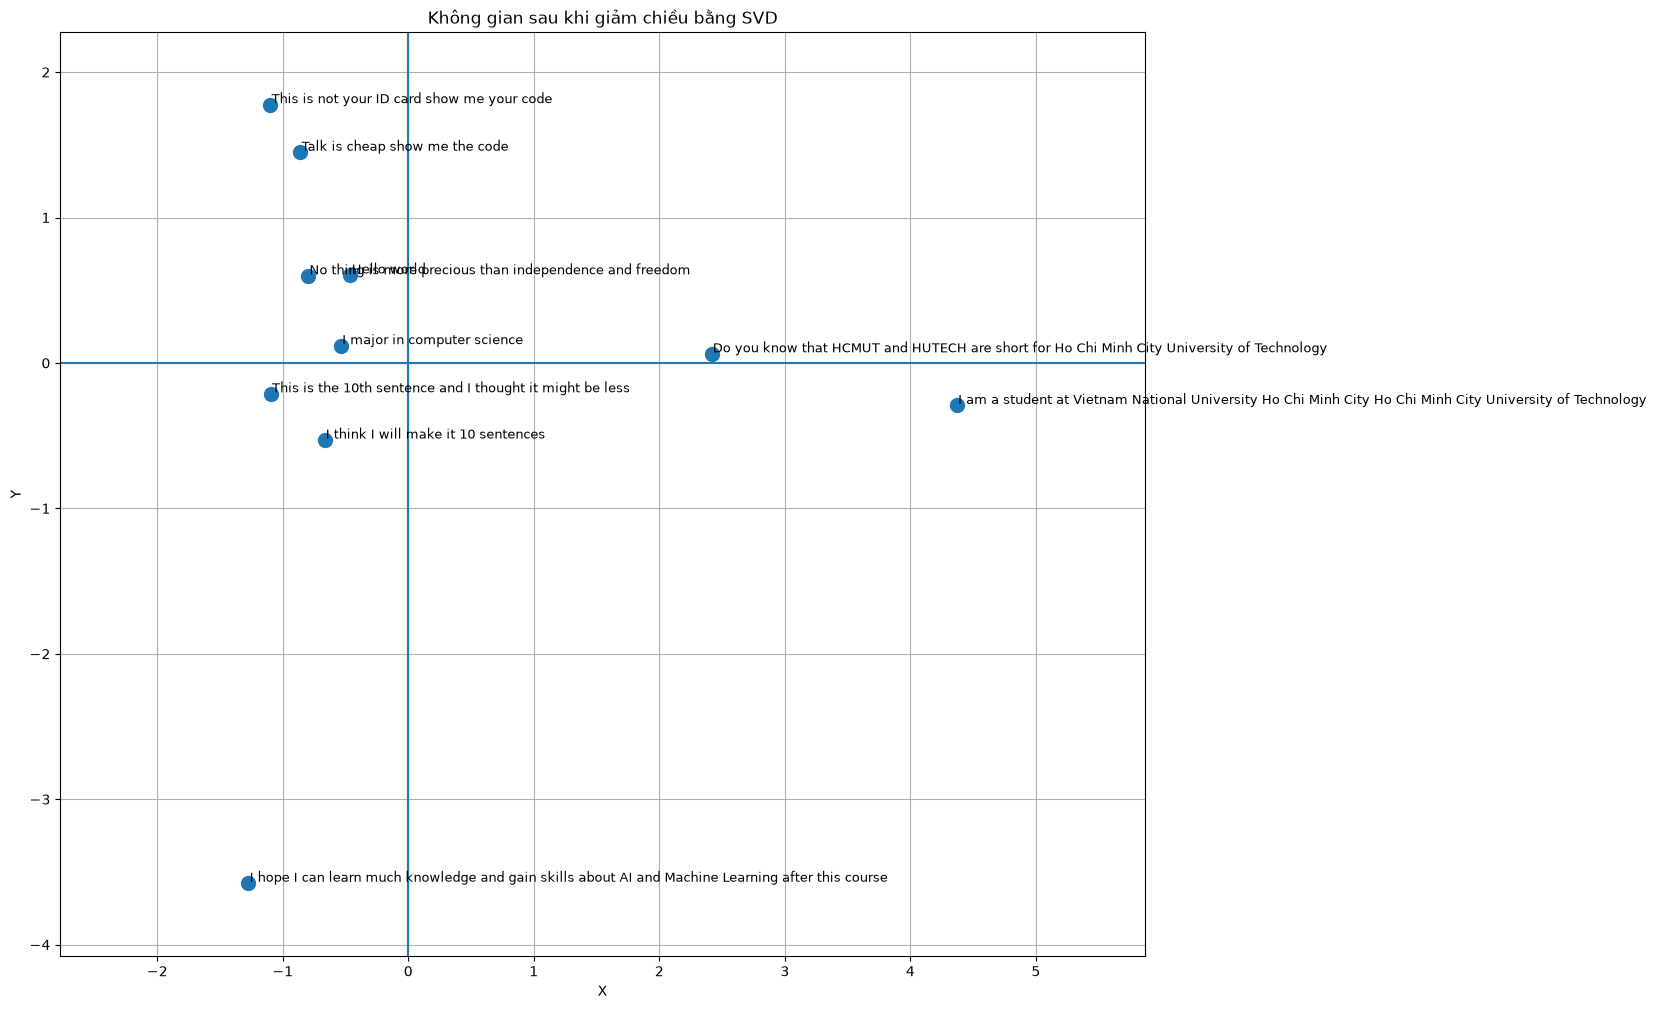

In [43]:
plt.figure(figsize=(14, 12))
plt.scatter(coords[:, 0], coords[:, 1], color='#1f77b4', s=100, zorder=3)

for i, text in enumerate(cau):
    plt.text(coords[i, 0] + 0.01, coords[i, 1] + 0.01, text, fontsize=9)

plt.xlim(coords[:, 0].min() - 1.5, coords[:, 0].max() + 1.5)
plt.ylim(coords[:, 1].min() - 0.5, coords[:, 1].max() + 0.5)

plt.title("Không gian sau khi giảm chiều bằng SVD")
plt.axhline(y=0)
plt.axvline(x=0)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

Vẽ scatter plot 2D để biểu diễn mối quan hệ giữa các điểm.

### 2.4. Nhận xét

Từ kết quả trực quan hóa bằng SVD, ma trận dữ liệu 74 chiều ban đầu được phân tách rõ rệt trên mặt phẳng 2D. Cảm giác như các câu về HCMUT thì ở bên phải, các câu thiên về code hay học thuật thì ở bên trái đồ thị. Nhìn chung là các câu có nội dung gần giống nhau thì ở gần nhau.

Qua đó, ta thấy SVD đã nén chiều hiệu quả và vẫn giữ được đặc trưng ngữ cảnh, tự động gom nhóm các câu có sự tương đồng và thể hiện nó trên đồ thị 2D một cách trực quan.